# Assignment 8: Ensemble Learning for Complex Regression Modeling on Bike Share Data 
In this assignment, I explored the application of **ensemble learning** techniques to a complex **bike rental demand** forecasting problem using the **UCI Bike Sharing Demand** dataset. The task involved predicting the total hourly count of rented bikes (`cnt`) based on temporal, seasonal, and weather-related features. Three major ensemble paradigms: `Bagging`, `Boosting`, and `Stacking` were implemented and compared against single baseline models (`Decision Tree Regressor` with max depth 6 and `Linear Regression`). Model performance was evaluated using Root Mean Squared Error (RMSE) to analyze how each ensemble approach addresses the bias-variance trade-off. The study emphasized how combining diverse learners through bagging, sequential correction, and meta-learning can yield improved generalization and predictive accuracy over individual models.

**Importing the necessary libraries**

We start our analysis by importing necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

**Random state for reproducibility**

In [2]:
RANDOM_STATE = 65

## Part A: Data Preprocessing and Baseline

### 1. Data Loading and Feature Engineering: 

In [3]:
df = pd.read_csv('hour.csv')

**Exploratory Data Analysis:**

In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


We can see that there are no-null values so we can proceed with further analysis.

In [7]:
df.shape

(17379, 17)

Target Distribution:

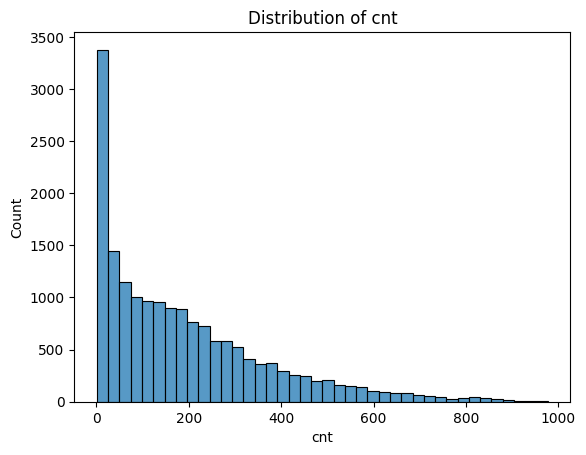

In [8]:
sns.histplot(df["cnt"], bins=40)
plt.title("Distribution of cnt")
plt.show()

**Visualizing some important columns:**

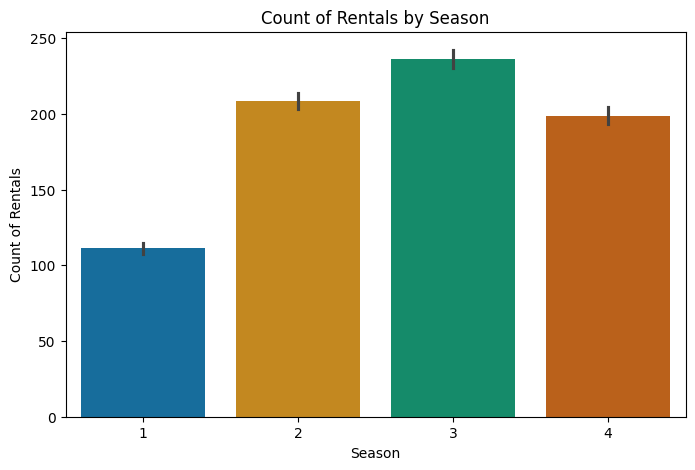

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data= df, palette='colorblind')
plt.title("Count of Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Count of Rentals")
plt.show()

We can see that rentals are highest in the summer season has been highest.

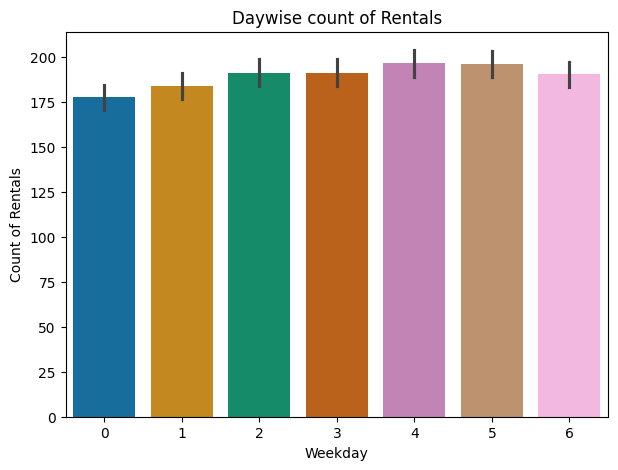

In [10]:
plt.figure(figsize=(7,5))
sns.barplot(x='weekday', y='cnt', data = df, palette='colorblind')
plt.title("Daywise count of Rentals")
plt.xlabel("Weekday")
plt.ylabel("Count of Rentals")
plt.show()

We can infer that rental counts are consistently high throughout the week, starting lowest on Day 0 and peaking towards the weekend on days 4, 5, and 6.

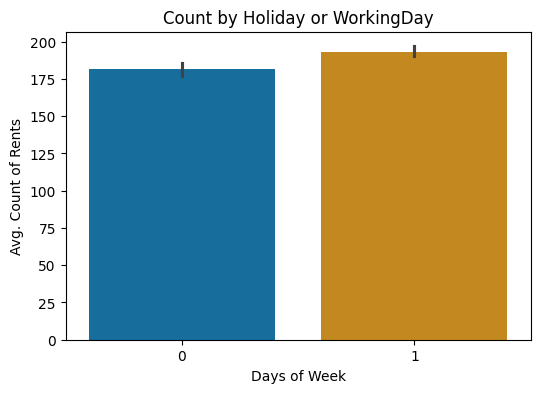

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x='workingday', y='cnt', data=df, palette='colorblind')
plt.title("Count by Holiday or WorkingDay")
plt.xlabel("Days of Week")
plt.ylabel("Avg. Count of Rents")
plt.show()

The plot clearly shows that the average rental count is slightly higher on working days than on non-working days (weekends or holidays).

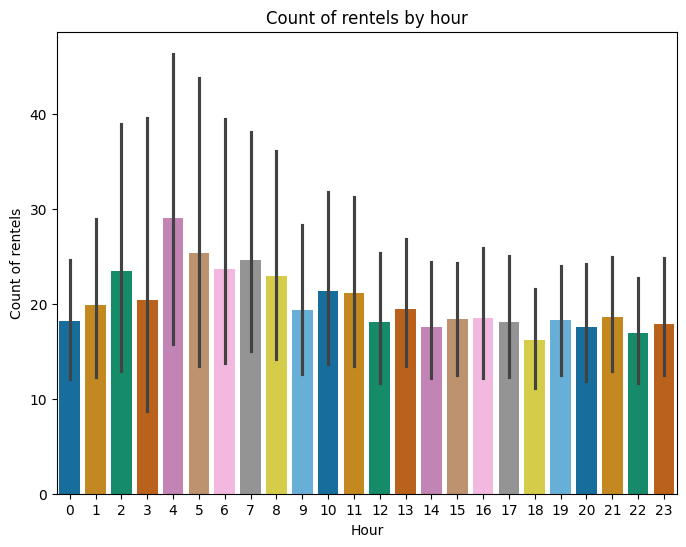

In [12]:
plt.figure(figsize=(8,6))
sns.barplot(x='hr', y=df['cnt'].value_counts(), data =df, palette='colorblind')
plt.title("Count of rentels by hour")
plt.xlabel("Hour")
plt.ylabel("Count of rentels")
plt.show()

We can see that rental demand is strongly time-dependent, with a significant morning peak around 5-7 AM likely due to commuter activity and lower demand during late night and midday hours.

**Dropping the irrelevant columns:**

There are some irrelevant columns like `instant`(just an index), `dteday` (date string, already decomposed), `registered` and `casual` (since cnt = registered + casual).

In [13]:
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


**Splitting in feature and target:**

In [14]:
X = df.drop(columns='cnt')
y = df['cnt']

**Converting the Categorical features to One-Hot Encoding**:

There are 6 categorical features (season, yr, mnth, hr, weekday, wethersit). We will convert them into onehot encoding and scale the numerical features for better results.

In [15]:
categorical_features = ['season','yr','mnth','hr','weekday','weathersit']
numerical_features = ['temp','atemp','hum','windspeed']

In [16]:
ct = ColumnTransformer(transformers=[
    ('one_hot_encoder', OneHotEncoder(), categorical_features),
    ('standard_scaler', StandardScaler(), numerical_features)
], remainder='passthrough')

X = ct.fit_transform(X)

In [19]:
X.shape

(17379, 59)

We can see that now df_final has 59 columns instead of earlier 13 columns due to one-hot encoding of the categorical columns.

### 2. Train/Test Split:

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [36]:
print(X_train.shape, X_test.shape)

(13903, 59) (3476, 59)


### 3. Baseline Model (Single Regressor): 

**Training a decision tree:**

In [42]:
dt = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,65
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


**Training Linear Regression tree:**

In [43]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Evaluating on both models:**

In [44]:
# Decsion Tree
y_pred_dt = best_dt.predict(X_test)
print(f'RMSE in Decision Tree: {root_mean_squared_error(y_pred_dt, y_test)}')

# Linear Regression
y_pred_lr = lr.predict(X_test)
print(f'RMSE in Linear Regression: {root_mean_squared_error(y_pred_lr, y_test)}')

RMSE in Decision Tree: 123.3154202368462
RMSE in Linear Regression: 101.32683437374925


We can see that **RMSE in Linear regression is less** so we will use it as our **baseline performance metric**.

## Part B: Ensemble Techniques for Bias and Variance Reduction

### 1. Bagging (Variance Reduction): 

**Hypothesis:** Bagging primarily targets variance reduction.

It does so by training multiple base models on random subsets of the data and averaging their predictions.

**Training a Bagging Regressor:**

In [45]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    n_estimators=80,           
    bootstrap=True,            # Sampling with replacement
    n_jobs=-1,                 
    random_state=RANDOM_STATE
)

bag_reg.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=65)
,n_estimators,80
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,65
,verbose,0


**Evaluating the Bagging Regressor:**

In [46]:
y_pred_bag = bag_reg.predict(X_test)
print("RMSE in Bagging Regressor:", root_mean_squared_error(y_test, y_pred_bag))

RMSE in Bagging Regressor: 116.59419120631024


The **Bagging Regressor** improved test performance, with RMSE decreasing from **123.31** to **116.59**.
This confirms that **bagging effectively reduced variance** compared to a single Decision Tree baseline.

### 2. Boosting (Bias Reduction):

**Hypothesis:** Boosting primarily targets bias reduction.

It does so by training models sequentially, where each new model learns to correct the errors (biases) of the previous ones.

**Training a Gradient Boosting Regressor:**

In [47]:
gbr = GradientBoostingRegressor(
    n_estimators=80,        # number of boosting stages
    learning_rate=0.1,       
    max_depth=6,             
    random_state=RANDOM_STATE
)

gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,80
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


**Evaluating the Gradient Boosting Regressor:**

In [48]:
y_pred_gbr = gbr.predict(X_test)
print("RMSE in Gradient Boosting Regressor:", root_mean_squared_error(y_test, y_pred_gbr))

RMSE in Gradient Boosting Regressor: 58.7408392909702


The **Gradient Boosting Regressor** achieved the **lowest RMSE (58.74)** among all models.
Compared to **baseline Linear Regression (101.33)** and **Bagging (116.59)**, Gradient Boosting produced significantly more accurate predictions.
This supports the hypothesis that **boosting primarily reduces bias**, it builds an ensemble of weak learners sequentially, where each learner focuses on the residual errors of the previous ones.

## Part C: Stacking for Optimal Performance

### 1. Stacking Implementation: 

- **Stacking** is an ensemble learning technique where **multiple diverse models** (base learners, also called **Level-0 models**) are trained to make predictions, and then another model (meta-learner or **Level-1 model**) learns how to best combine those predictions to produce the final output.

- The **Meta-learner** takes these predictions as inputs and learns how to combine them optimally. **It assigns weights to each base learner’s output, giving more importance to models that predict more accurately.**

**Defining the Base Learners (Level-0):**

In [49]:
# KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)

# Bagging Regressor
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    n_estimators=80,           
    bootstrap=True,            # Sampling with replacement
    n_jobs=-1,                 
    random_state=RANDOM_STATE
)

# Graident Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=80,        # number of boosting stages
    learning_rate=0.1,       
    max_depth=6,             
    random_state=RANDOM_STATE
)

**Defining the Meta-Learner (Level-1): Ridge Regression model** 

In [50]:
meta_learner = Ridge(alpha=0.01)

**Implementing a Stacking Regressor:**

In [51]:
stacking_reg = StackingRegressor(
    estimators=[
        ('knn', knn_reg),
        ('bagging', bag_reg),
        ('gboost', gbr)
    ],
    final_estimator=meta_learner,
    n_jobs=-1
)

# Train the Stacking Regressor
stacking_reg.fit(X_train, y_train)

,estimators,"[('knn', ...), ('bagging', ...), ...]"
,final_estimator,Ridge(alpha=0.01)
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


### 2. Final Evaluation: 

In [52]:
y_pred_stack = stacking_reg.predict(X_test)
rmse_stack = root_mean_squared_error(y_test, y_pred_stack)

print(f"RMSE in Stacking Regressor: {rmse_stack}")

RMSE in Stacking Regressor: 55.52132907992873


## Part D: Final Analysis

### 1. Comparative Table:

In [53]:
summary = {
    'Model': [
        'Baseline (Linear Regression)',
        'Bagging Regressor',
        'Gradient Boosting Regressor',
        'Stacking Regressor'
    ],
    'RMSE': [
        101.33,
        116.59,
        58.74,
        55.52
    ]
}

results_df = pd.DataFrame(summary)
print(results_df)

                          Model    RMSE
0  Baseline (Linear Regression)  101.33
1             Bagging Regressor  116.59
2   Gradient Boosting Regressor   58.74
3            Stacking Regressor   55.52


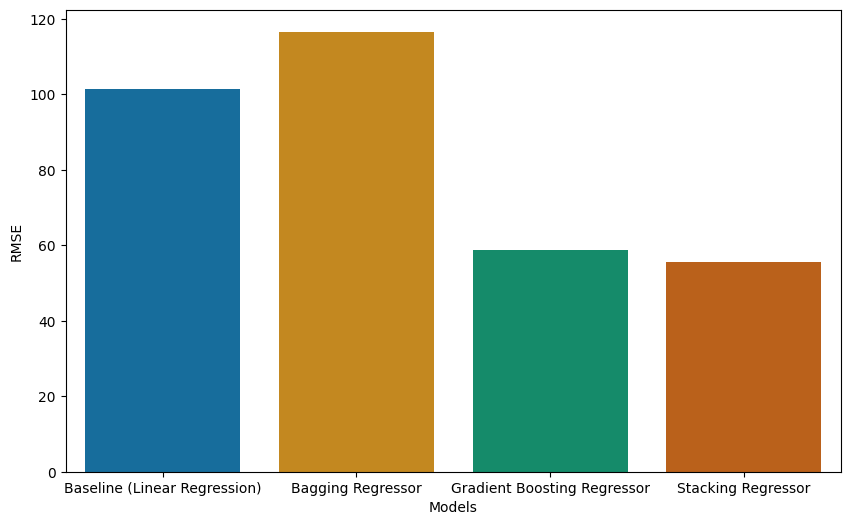

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df['Model'], y=results_df['RMSE'], palette='colorblind')
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.show()

### 2. Conclusion:

- **Stacking Regressor** is the **best-performing model** with RMSE of 55.52.
- The **Stacking Regressor** achieved the best generalization performance with the lowest RMSE, confirming that combining diverse learners using a meta-learner effectively balances the **bias–variance trade-off**.
While the single models (Decision Tree, Linear Regression) suffered from either overfitting or underfitting, and bagging/boosting addressed only one side of the trade-off, stacking used **model diversity** successfully to integrate their strengths to produce the most robust and accurate predictions.